## Exercise 2: Transfer learning

1. Load the following dataset containing thousands of images of cats and dogs:
    ```python
    dataset_url = "https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip"
    path_to_zip = tf.keras.utils.get_file('cats_and_dogs.zip', origin=dataset_url, extract=True)
    path = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')
    train_dir = pathlib.Path(path) / 'train'
    validation_dir = pathlib.Path(path) / 'validation'
    ```

2. Construct a training and validation dataset using `tf.keras.utils.image_dataset_from_directory`, 20% split, 32 batch sizes. Inspect the training dataset by plotting image samples. Prefetch data following the same approach implemented in the previous exercise.

3. Construct a data augmentation model with horizontal random flip and rotation (0.2). Plot samples of augmented data.

4. Allocate a MobileNetV2 base model passing the input image shape, excluding the classification layers at the top of the model (`include_top=False`) and using weights from ImageNet (`weights='imagenet'`). Freeze this model by calling `base_model.trainable = False`.

5. Construct the final model using the functional API. The input passes through: a data augmentation layer, a preprocessing input (which normalizes images for MobileNetV2) using `tf.keras.applications.mobilenet_v2.preprocess_input`, the freeze base model MobileNetV2, an average over the spatial locations using `tf.keras.layers.GlobalAveragePooling2D()`, a dropout layer (0.2), and finally a dense layer with a single unit. The network output should be considered as logit, i.e. positive numbers predict class 1 while negative class 0.

6. Train the model with Adam and learning rate 1e-4, binary cross-entropy loss function and few epochs (< 10). Monitor and plot the loss function and accuracy for each epoch, for training and validation sets.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os 
import pathlib

2025-05-23 17:31:15.412171: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-23 17:31:15.415128: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-23 17:31:15.423007: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748014275.435989    8656 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748014275.439624    8656 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-23 17:31:15.454056: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [2]:
dataset_url = "https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip"
path_to_zip = tf.keras.utils.get_file('cats_and_dogs.zip', origin=dataset_url, extract=True)
path = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_extracted/cats_and_dogs_filtered')
train_dir = pathlib.Path(path) / 'train'
validation_dir = pathlib.Path(path) / 'validation'

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
['cats', 'dogs']


2025-05-23 17:31:17.431079: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-05-23 17:31:17.816749: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


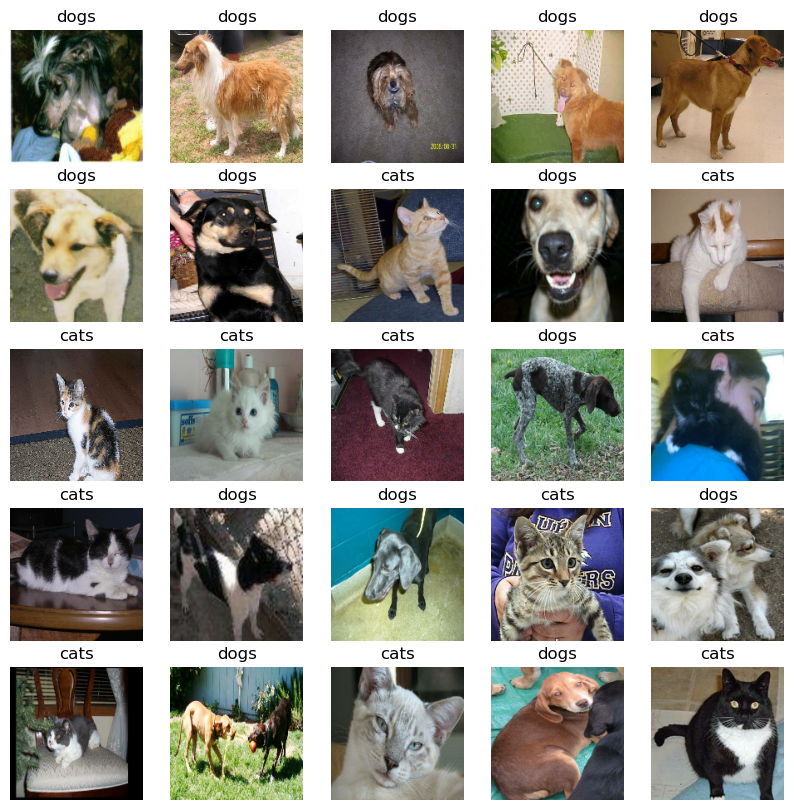

In [3]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=123,
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
class_names = train_dataset.class_names
print(class_names)

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(25):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [4]:
train_ds = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = validation_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
])

IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False # Freeze the base model, untrainable


In [7]:
inputs = tf.keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1)(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 238ms/step - accuracy: 0.6115 - loss: 0.6730 - val_accuracy: 0.7660 - val_loss: 0.4651
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 220ms/step - accuracy: 0.7293 - loss: 0.5120 - val_accuracy: 0.8470 - val_loss: 0.3416
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 221ms/step - accuracy: 0.8003 - loss: 0.4140 - val_accuracy: 0.8860 - val_loss: 0.2693
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 222ms/step - accuracy: 0.8613 - loss: 0.3274 - val_accuracy: 0.9050 - val_loss: 0.2222
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 223ms/step - accuracy: 0.8624 - loss: 0.2967 - val_accuracy: 0.9290 - val_loss: 0.1908
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 220ms/step - accuracy: 0.8715 - loss: 0.2773 - val_accuracy: 0.9360 - val_loss: 0.1678
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 222ms/step - accuracy: 0.8934 - loss: 0.2581 - val_accuracy: 0.9430 - val_loss: 0.1517
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 220ms/step - accuracy: 0.9029 - loss: 0.2416 - val_accu

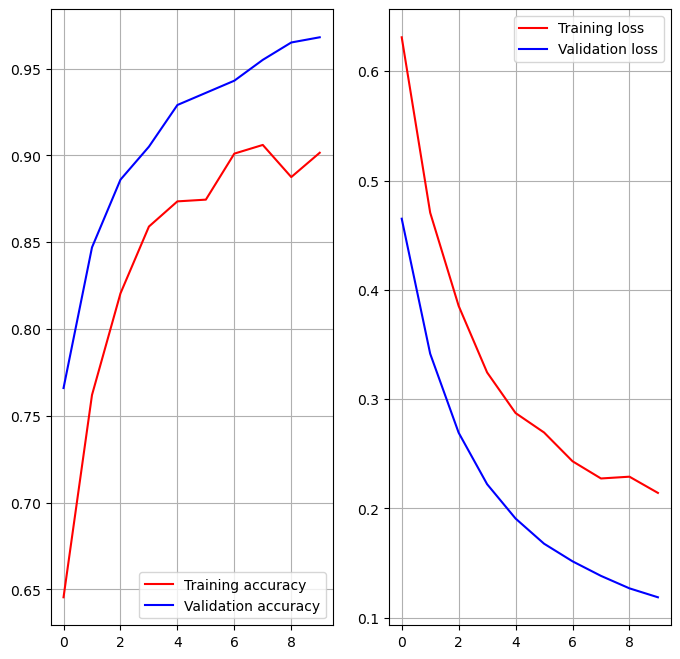

In [9]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(history.epoch, acc, 'r', label='Training accuracy')
plt.plot(history.epoch, val_acc, 'b', label='Validation accuracy')
plt.legend(loc='lower right')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.epoch, loss, 'r', label='Training loss')
plt.plot(history.epoch, val_loss, 'b', label='Validation loss')
plt.legend(loc='upper right')
plt.grid()
plt.show()